# <b>Capstone Project: Population, environmental resources strain, and housing</b>
Author: Chong An Ong
<br>Date: March 10 2026</br>
- (Note: In real-world project collaboration, this is good practice so people know when this code was last worked on)

## Research Question: 
#### Population growth --> Pressure on environmental resources --> Impact on housing development
- How are housing prices affected by environmental amenities?
- Does population growth affect environmental resource use / strain and consequently housing prices / growth?

Link to GitHub repository: [GitHub Repository](<insert link here>)

In [8]:
# 0. housekeeping ---------------------------------------------------------

library(tigris)
library(tidyverse)
library(tidyterra)
library(terra)
library(sf)
library(readxl)

To enable caching of data, set `options(tigris_use_cache = TRUE)`
in your R script or .Rprofile.



── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     


── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors



Attaching package: ‘tidyterra’




The following object is masked from ‘package:stats’:

    filter




terra 1.8.70




Attaching package: ‘terra’




The following object is masked from ‘package:tidyr’:

    extract




The following object is masked from ‘package:tigris’:

    blocks




Linking to GEOS 3.12.1, GDAL 3.8.4, PROJ 9.4.0; sf_use_s2() is TRUE



## Data
#### Population data: from US Census

Each year, the United States Census Bureau produces and publishes estimates of the population for the nation, states, metropolitan and micropolitan statistical areas, counties, state/county equivalents, and Puerto Rico. We estimate the resident population for each year since the most recent decennial census by using measures of population change. The resident population includes all people currently residing in the United States.

The data I draw from the US Census includes births, deaths, international and domestic migration, and a residual component that is calculated as the difference between the balancing equation and the final population estimate. (To add: some information about what the balancing equation is about.)

#### Housing data: from Federal Housing Finance Agency

The FHFA House Price Index® (FHFA HPI®) is a comprehensive​ collection of publicly available house price indexes that measure changes in single-family home values based on data that extend back to the mid-1970s from all 50 states and over 400 American cities. The FHFA HPI® incorporates tens of millions of home sales and offers insights about house price fluctuations at the national, census division, state, metro area, county, ZIP code, and census tract levels.  FHFA uses a fully transparent methodology based upon a weighted, repeat-sales statistical technique to analyze house price transaction data.

###### What does the FHFA HPI® represent?

The FHFA HPI® is a broad measure of the movement of single-family house prices. The FHFA HPI® is a weighted, repeat-sales index, meaning that it measures average price changes in repeat sales or refinancings on the same properties. This information is obtained by reviewing repeat mortgage transactions on single-family properties whose mortgages have been purchased or securitized by Fannie Mae or Freddie Mac since January 1975.

The FHFA HPI® serves as a timely, accurate indicator of house price trends at various geographic levels. Because of the breadth of the sample, it provides more information than is available in other house price indexes. It also provides housing economists with an improved analytical tool that is useful for estimating changes in the rates of mortgage defaults, prepayments and housing affordability in specific geographic areas.

#### How did I clean the data? 

See below documentation - files had to be read in by decade. Files had a standard format from 2000-2024, but I had to separately write code to process the files from 1990-2000. 

In [0]:
# 1a. read in census data (1990-2024) -------------------------------------

# helper func for reading census data
read_census <- function(filename){
  df <- read.csv(filename) %>%
    # keep county-level only
    filter(SUMLEV!=40) %>%
    # generate fips code
    mutate(fips=str_pad(STATE*1000+COUNTY,5,pad='0'))%>%
    # keep only state name, county name, fips code, pop vars
    select(-(1:5)) %>% 
    rename(state=STNAME,county=CTYNAME) %>%
    mutate(state=str_squish(state),
           county=str_squish(county))
  df <- df %>%
    # coerce any character cols to numeric cols 
    # this happens for the census estimates every decade
    mutate(across(3:ncol(df), as.numeric)) %>%
    # pivot to county-var-year level
    pivot_longer(!c(state,county,fips)) %>%
    # split col names into var and year
    mutate(var=tolower(str_replace_all(name, "\\d","")),
           year=as.numeric(tolower(str_replace_all(name, "\\D","")))) %>%
    select(-name)
  return(df)
}

# 2020-2024 
cs24 <- read_census('data/census/co-est2024-alldata.csv') %>%
  # remove all *2020 variables: * from apr 1 2020 to jul 1 2020
  # this is to deconflict with variables in the 2010-2020 census files
  # which refer to * from jul 1 2019 to jul 1 2020
  filter(year!=2020)

# 2010-2020 
cs20 <- read_census('data/census/co-est2020-alldata.csv') %>%
  # ditto
  filter(year!=2010)

# 2000-2010 
cs10 <- read_census('data/census/co-est2010-alldata.csv') %>%
  # ditto
  filter(year!=2000)

# 1990-2000 
# different format than the other intercensal files
# 1 .txt per state, 10 tables per .txt

# download txt files first (if not already downloaded)

download_1990_2000_intercensal <- "F"

if (download_1990_2000_intercensal){
  state_fips <- c("01","02","04","05","06","08","09","10","11","12", 
                  "13","15","16","17","18","19","20","21","22","23",
                  "24","25","26","27","28","29","30","31","32","33",
                  "34","35","36","37","38","39","40","41","42","44",
                  "45","46","47","48","49","50","51","53","54","55","56")
  
  base_url <- paste0("https://www2.census.gov/programs-surveys/",
                     "popest/tables/1990-2000/estimates-and-caqhange-1990-2000/")
  
  output_dir <- "census_txt_files"
  if (!dir.exists(output_dir)) dir.create(output_dir)
  
  for (fips in state_fips) {
    file_name <- paste0("2000c8_", fips, ".txt")
    url <- paste0(base_url, file_name)
    dest <- file.path(output_dir, file_name)
    
    message("Downloading ", file_name)
    
    tryCatch({
      download.file(url, destfile = dest, mode = "wb")
    }, error = function(e) {
      warning("Failed to download: ", url)
    })
  }
}

# new helper function for 1990-2000 intercensal files
read_census00 <- function(filename){
  cat("Processsing file:", filename, "\n")
  # read in each line of .txt as elements of a character-type vector
  lines <- read_lines(filename)
  
  # filter for only rows that contain tabular data
  table_rows <- lines %>%
    str_subset("^\\s*\\d+\\s+\\d{2,5}\\s+")
  
  # convert character-type vector into combined data-frame
  parsed <- table_rows %>%
    tibble(raw = .) %>%
    mutate(
      # split on whitespace
      parts = str_split(raw, "\\s+"),
      # extract first two columns (table # - "block" - and fips)
      block = map_int(parts, ~ as.integer(.x[1])),
      fips  = map_chr(parts, ~ .x[2]),
      # extract remaining numeric values 
      values = map(
        parts,
        ~ .x[-c(1, 2)][str_detect(.x[-c(1, 2)], "^-?\\d|,")]
      ),
      # extract area name (state or county)
      area = map_chr(parts, ~ paste(.x[!str_detect(.x, "\\d")], collapse = " "))
    ) %>%
    # clean values
    # remove commas, convert to numeric
    mutate(
      values = map(values, ~ as.numeric(str_remove_all(.x, ",")))
    ) %>%
    # split into columns
    unnest_wider(values, names_sep = "_") %>%
    select(-raw,-parts) %>% 
    # pivot to block-fips level
    pivot_longer(!c(block, fips, area)) %>%
    # add variable labels (we will match to the later census datasets)
    # block numbers correspond to:
    # 1: pop
    # 2: pop >=65 - we'll drop this
    # 3: pop <65 - we'll drop this
    # 4: births
    # 5: deaths
    # 6: net int'l migration
    # 7: net federal movement (folded into domestic migration for subsequent censuses)
    # 8: net domestic migration
    # 9: residual
    # 10: group quarters
    # value numbers correspond to:
    # for blocks 1 to 3: 
    # 1-11: as of jul 1 2000-1990
    # 12: as of apr 1 1990 (i.e. census 1990)
    # for blocks 4 to 9: 
    # 1: cumulative from apr 1 1990 to jul 1 2000
    # 2-11: from jul 1 2000-1991 to year before
    # 12: from jul 1 1990 to apr 1 1990
    # for block 10:
    # 1-10: from jul 1 2000-1991 to year before
    # 11: from jul 1 1990 to apr 1 1990
    mutate(var=case_when(
      block == 1 ~ "popestimate",
      block == 2 ~ "popestimate_geq65",
      block == 3 ~ "popestimate_u65",
      block == 4 ~ "births",
      block == 5 ~ "deaths", 
      block == 6 ~ "internationalmig",
      block == 7 ~ "federalmovement",
      block == 8 ~ "domesticmig",
      block == 9 ~ "residual",
      block == 10 ~ "gqestimates"
    ),
    value_num = as.numeric(gsub("values_","",name)),
    year=case_when(
      block %in% 1:3 & value_num !=12 ~ 2000-value_num+1,
      # census (apr 1) 1990 flag 
      # the analog var is census20X0pop in later files 
      # but we dropped this var when reading in the later files above
      # so we'll drop this for the 1990-2000 files as well
      block %in% 1:3 & value_num ==12 ~ -1,
      block %in% 4:9 & value_num ==1  ~ 9999, # denotes cumulative for multiple years
      block %in% 4:9 & value_num !=1  ~ 2000-value_num+2,
      block == 10                     ~ 2000-value_num+1
      )
    ) %>% 
    select(-name,-block,-value_num)
  
  # drop the census1990pop var and the cumulative column
  parsed <- parsed %>% filter(year>0 | year == 9999)

  # remove state-level rows, create state column
  
  state_name <- unique((parsed %>% filter(str_length(fips)==2))$area)
  parsed <- parsed %>% 
    filter(str_length(fips)!=2) %>% 
    mutate(state=str_squish(state_name),
           county=str_squish(area),
           fips=as.numeric(fips)) %>% select(-area)
  
  # combine federal movement and domestic migration numbers
  # for comparability with later years
  
  parsed_subset <- parsed %>% 
    filter(var %in% c("federalmovement","domesticmig")) %>%
    pivot_wider(names_from=var) %>%
    mutate(total=federalmovement+domesticmig) %>% 
    select(-federalmovement,-domesticmig) %>% 
    rename(value = total) %>% 
    mutate(var = "domesticmig")
  
  return(parsed %>% 
           filter(!var%in%c("federalmovement","domesticmig")) %>%
           bind_rows(parsed_subset))
}

setwd('census_txt_files')
# process all downloaded files and combine into one dataset
cs00 <- lapply(list.files(),read_census00) %>% bind_rows() 
setwd('..')

# stack all the census datafiles from 1990-2024
cs <- bind_rows(cs00,
                cs10,
                cs20,
                cs24)


Our final cleaned data looks like this: 4 different census files stacked on top of each other, long format where each row represents one of several demographic variables for each county and each year. 

In [10]:
head(cs)
cs$var%>%unique()

,fips,value,var,year,state,county
,<int>,<int>,<chr>,<int>,<chr>,<chr>
1,1001,43981,popestimate,2000,Alabama,Autauga County
2,1001,43021,popestimate,1999,Alabama,Autauga County
3,1001,42156,popestimate,1998,Alabama,Autauga County
4,1001,41280,popestimate,1997,Alabama,Autauga County
5,1001,40241,popestimate,1996,Alabama,Autauga County
6,1001,39140,popestimate,1995,Alabama,Autauga County


[1] "popestimate"      "births"           "deaths"           "internationalmig"
 [5] "residual"         "gqestimates"      "domesticmig"      "npopchg"         
 [9] "naturalinc"       "netmig"           "naturalchg"

In [11]:
# 1b. additional cleaning for census data ---------------------------------

# quick glimpse of what variables we have
cs$var %>% unique()

# npopchg has an additional underscore for years 2000-2024
# we also drop the population by age tables that we don't need
# and the rate variables that we don't need
cs <- cs %>%
  filter(!(var %in% c("popestimate_geq65", "popestimate_u65"))) %>% 
  mutate(var=str_replace(var,"_","")) %>%
  filter(var=="residual" | !grepl("^r",var))
cs$var %>% unique()

# CT remaps their counties in 2022
# Let's not deal with CT for now
cs <- cs %>% filter(state!="Connecticut")

# we will now construct our yearly county population + migration estimates
# take a snapshot of 2024 counties + their population as of jul 1 2024
counties_pop_24 <- cs %>% filter(year==2024 & var=="popestimate") 

# code to check that npopchg in year t is correctly calculating
# diffs in popestimate from year t-1 to year t
# EXCEPT at the first year of every decade 
# as expected when backcasting using intercensal files
if(0){
  check <- df %>%
    filter(var %in% c("popestimate", "npopchg")) %>%
    pivot_wider(
      names_from = var,
      values_from = value
    ) %>%
    arrange(fips, year) %>%
    group_by(fips) %>%
    mutate(
      implied_npopchg = popestimate - lag(popestimate),
      diff = npopchg - implied_npopchg
    ) %>%
    ungroup()
  check %>% head()
  (check%>%filter(diff!=0))$year %>% table()
}

# backcast using npopchg var
# extract the npopchg var table first
counties_npopchg <- cs %>% filter(var=="npopchg") %>%
  bind_rows(cs %>% filter(year%in%1990:2000 & var=="popestimate") %>%
              rename(tmp=value) %>%
              group_by(state,county)%>%
              arrange(state,county,year)%>%
              mutate(value=tmp-lag(tmp)) %>%
              select(-tmp,-var) %>%
              mutate(var='npopchg') %>% filter(!is.na(value)))

# loop to backcast population in year T-1 given population in year T
start_year <- 2024
end_year <- 1990
counties_pop <- counties_pop_24

for (i in 1:(start_year-end_year)){
  t <- start_year - i + 1
  cat("Backcasting for year:",t-1,"\n")
  tmp <- counties_pop %>% select(-var) %>% 
    rename(pop=value) %>% filter(year==t) %>%
    left_join(counties_npopchg %>% select(-var) %>% 
                rename(npopchg=value) %>% filter(year==t)) %>%
    mutate(var="popestimate", value=pop-npopchg, year=year-1) %>%
    select(-pop,-npopchg)
  
  counties_pop <- counties_pop %>% bind_rows(tmp)
}

counties_mig <- cs %>% 
  filter(var%in%c("domesticmig","internationalmig","netmig")) %>%
  pivot_wider(names_from=var) %>%
  mutate(netmig=ifelse(is.na(netmig), domesticmig+internationalmig, netmig)) %>%
  filter(year!=9999) %>% arrange(state,county,year)

[1] "popestimate"      "births"           "deaths"           "internationalmig"
 [5] "residual"         "gqestimates"      "domesticmig"      "npopchg"         
 [9] "naturalinc"       "netmig"           "naturalchg"

[1] "popestimate"      "births"           "deaths"           "internationalmig"
 [5] "residual"         "gqestimates"      "domesticmig"      "npopchg"         
 [9] "naturalinc"       "netmig"           "naturalchg"

Backcasting for year: 2023 


Joining with `by = join_by(fips, year, state, county)`


Backcasting for year: 2022 


...

Joining with `by = join_by(fips, year, state, county)`


Backcasting for year: 1991 


Joining with `by = join_by(fips, year, state, county)`


Backcasting for year: 1990 


Joining with `by = join_by(fips, year, state, county)`


## Population Findings

Some sentences about my findings here

Joining with `by = join_by(fips, year, state, county)`


`summarise()` has grouped output by 'state'. You can override using the
`.groups` argument.


Retrieving data for the year 2024



  |                                                                      |   0%

  |                                                                      |   1%

...

  |=======================================================               |  78%

  |=================================================================     |  92%

  |======================================================================| 100%

Retrieving data for the year 2024



Joining with `by = join_by(GEOID)`


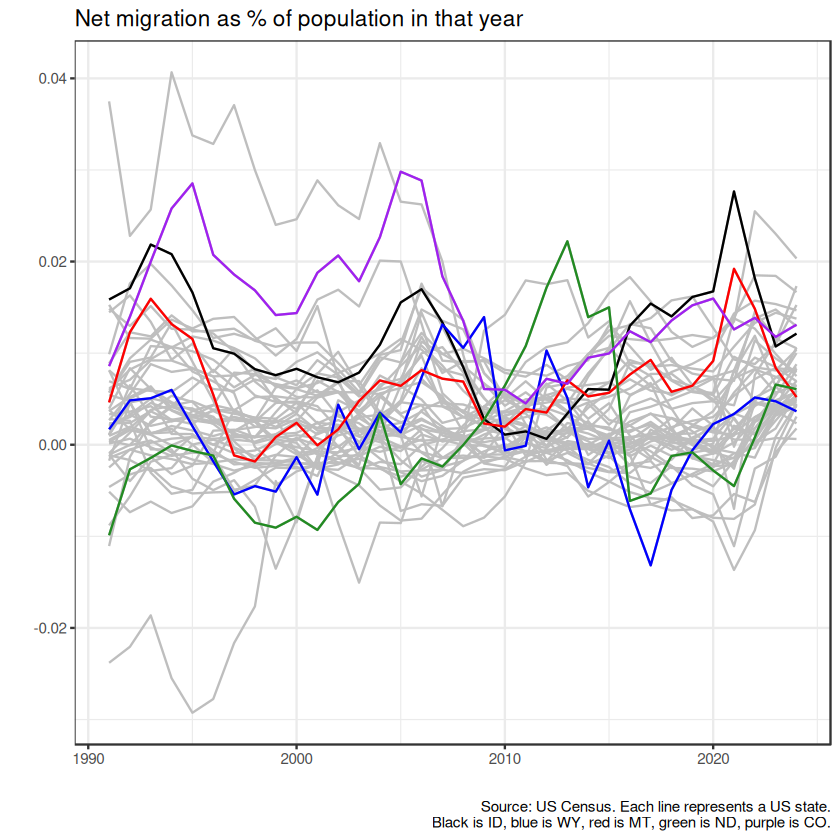

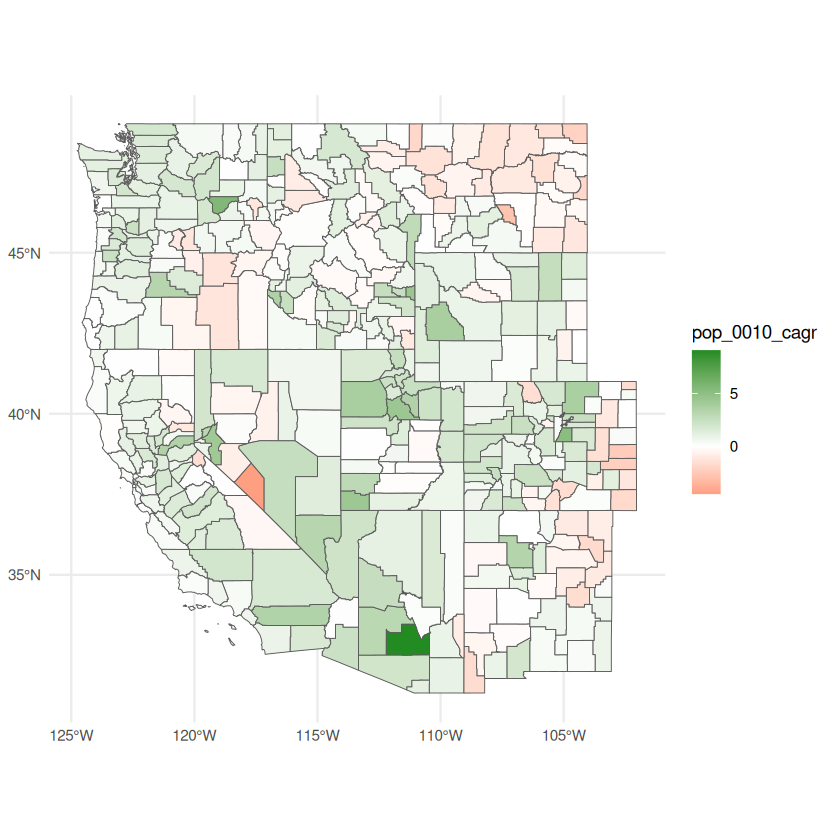

In [12]:
# 2. census population plots ----------------------------------------------

df <- counties_pop %>% rename(pop=value) %>% select(-var) %>%
  left_join(counties_mig)
df_st <- df %>% 
  filter(state!="Alaska" & state != "Louisiana") %>%
  group_by(state,year) %>% 
  summarise(pop=sum(pop,na.rm=T),mig=sum(netmig,na.rm=T)) %>%
  mutate(mig_pct=mig/pop) %>% filter(year!=1990)

df_st %>% 
  ggplot(aes(x=year,y=mig_pct,group=state)) + 
  geom_line(color='grey') + 
  geom_line(color='black',data=df_st%>%filter(state%in%c("Idaho"))) + 
  geom_line(color='blue',data=df_st%>%filter(state%in%c("Wyoming"))) + 
  geom_line(color='red',data=df_st%>%filter(state%in%c("Montana"))) + 
  geom_line(color='forestgreen',data=df_st%>%filter(state%in%c("North Dakota"))) + 
  geom_line(color='purple',data=df_st%>%filter(state%in%c("Arizona"))) +
  theme_bw()+
  labs(x="",y="",
       title="Net migration as % of population in that year",
       caption="Source: US Census. Each line represents a US state.\nBlack is ID, blue is WY, red is MT, green is ND, purple is CO.")

df_pop <- counties_pop %>% group_by(fips) %>%
  filter(year%in%c(1990,2000,2010,2020,2024)) %>% 
  pivot_wider(names_from=year,names_prefix="pop_") %>%
  mutate(fips=str_pad(fips,5,pad="0"),
         pop_9024_cagr=(pop_2024/pop_1990)^(1/34)*100-100,
         pop_2024_cagr=(pop_2024/pop_2020)^(1/4)*100-100,
         pop_9000_cagr=(pop_2000/pop_1990)^(1/10)*100-100,
         pop_0010_cagr=(pop_2010/pop_2000)^(1/10)*100-100,
         pop_1020_cagr=(pop_2020/pop_2010)^(1/10)*100-100) %>%
  select(GEOID=fips,ends_with("cagr"))

us_counties <- counties(state=c('AL','AZ','AR','CA','CO','CT','DE','FL','GA',
                                'ID','IL','IN','IA','KS','KY','LA','ME','MD',
                                'MA','MI','MN','MS','MO','MT','NE','NV','NH',
                                'NJ','NM','NY','NC','ND','OH','OK','OR','PA',
                                'RI','SC','SD','TN','TX','UT','VT','VA','WA',
                                'WV','WI','WY'),
                        cb=T)
west_counties <- counties(state=c('MT', 'WY', 'CO', 'NM', 'AZ', 'UT', 
                                  'ID', 'WA', 'OR', 'NV', 'CA'),
                          cb=T)

west_counties %>% left_join(df_pop) %>%
  ggplot(aes(fill=pop_0010_cagr))+
    theme_minimal()+
    geom_sf()+
    scale_fill_gradient2(low="red",mid='white',high="forestgreen") 

## Housing price findings

Some general thoughts about trends here: which areas and periods saw faster housing inflation? 

Warning message:
“There was 1 warning in `mutate()`.
ℹ In argument: `hpi = as.numeric(hpi)`.
Caused by warning:
! NAs introduced by coercion”


Retrieving data for the year 2024



Joining with `by = join_by(GEOID)`


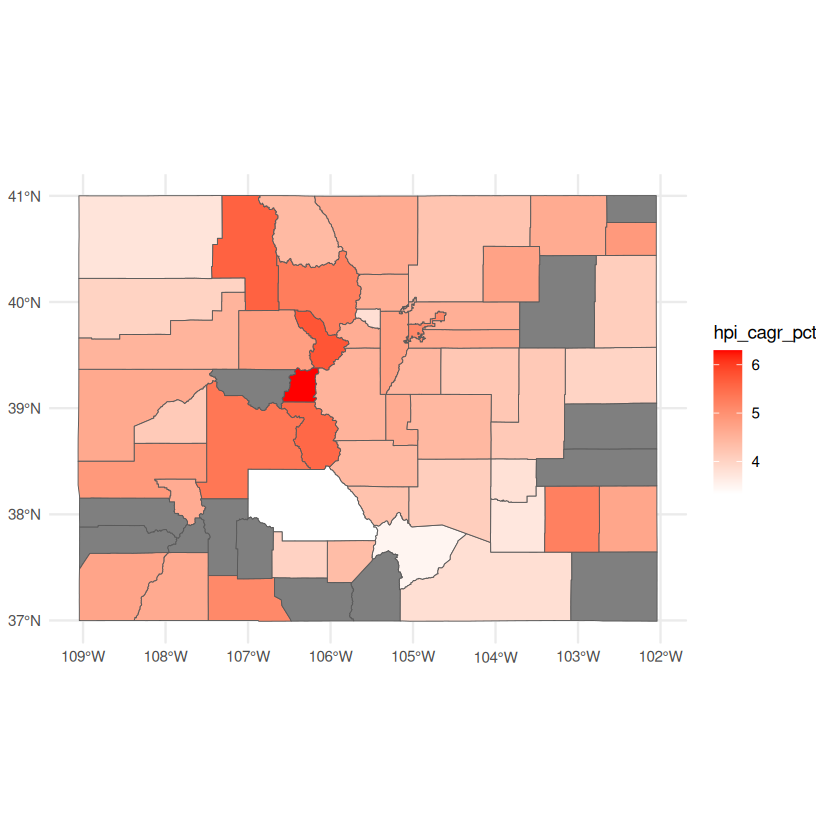

In [15]:
# 3a. read in hpi data (variable years) -----------------------------------

# much less cleaning needed for this - data is already very close to how we want it
hpi <- read_excel('data/hpi_at_bdl_county.xlsx',skip=6) %>%
  select(state=1,county=2,fips=3,year=4,hpi=6) %>%
  mutate(year=as.numeric(year), hpi=as.numeric(hpi))


# 3b. hpi plots -----------------------------------------------------------

co_hpi <- hpi %>% group_by(fips) %>% 
  filter(state=="CO" & min(year)<=2003 & 
           (year==2003 | year==2023)) %>% 
  pivot_wider(names_from=year,names_prefix="hpi_",values_from=hpi) %>%
  mutate(hpi_cagr_pct=(hpi_2023/hpi_2003)^.05*100-100)
co_counties <- counties(state='CO',cb=T)
co_counties %>% left_join(co_hpi %>% rename(GEOID=fips)) %>%
  ggplot(aes(fill=hpi_cagr_pct))+theme_minimal()+geom_sf()+scale_fill_gradient(low="white",high="red")


## Implications for environmental resource strain

Additional thoughts and visualizations here

## Closing thoughts

- Limitations of my study
- Directions for future research